## Probabilistic Model to Estimate Power Output

In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import beta, weibull_min, gamma, norm, lognorm, cauchy, kstest
from sklearn.metrics import mean_squared_error
import warnings

In [2]:
df = pd.read_csv('../data/processed/dataset.csv').drop(columns=['Unnamed: 0'])
# drop nans and power outliers
df = df[df['power'] < 20000].dropna().reset_index(drop=True)

Text(0, 0.5, 'Power Output')

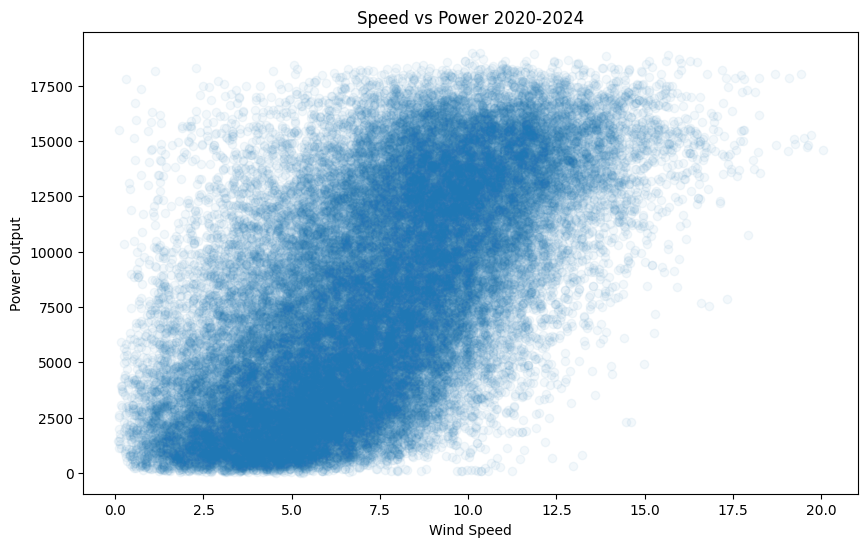

In [3]:
plt.figure(figsize=(10, 6))
plt.scatter(df['speed'], df['power'], alpha=0.05)
plt.title('Speed vs Power 2020-2024')
plt.xlabel('Wind Speed')
plt.ylabel('Power Output')

In [4]:
intervals1 = [0, 4, 12, 20]
intervals2 = [0, 2.5, 5, 7.5, 10, 12.5, 15, 17.5, 20]
intervals3 = [0, 2.5, 5, 5.5, 6, 6.5, 7, 7.5, 8, 8.5, 9, 9.5, 10, 11, 12, 14, 17, 20]

Text(0, 0.5, 'Frequency')

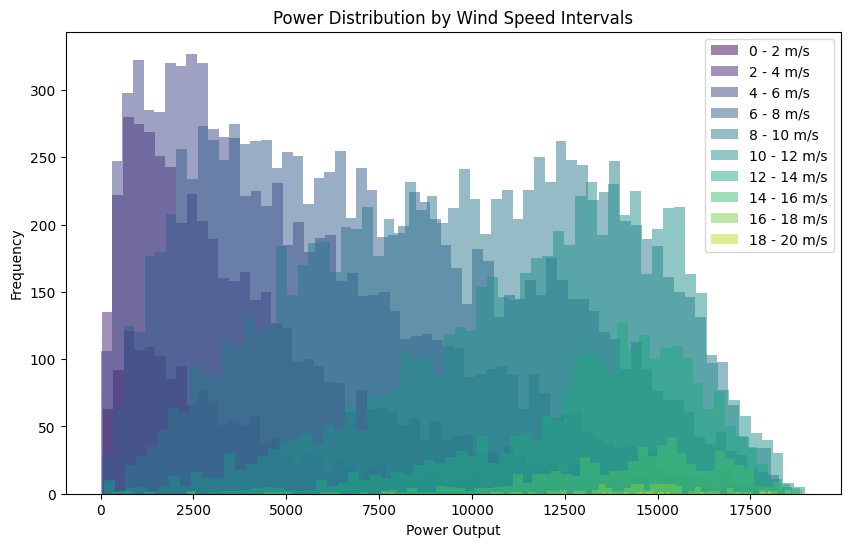

In [5]:
# even wind speed intervals plot
interval = 2
bins = 64

fig, ax = plt.subplots(figsize=(10, 6))
i = 0
while i < 20:
    df_temp = df[(df['speed'] >= i) & (df['speed'] < i + interval)]
    ax.hist(df_temp['power'], bins=bins, alpha=0.5, label=f'{i} - {i + interval} m/s', color=plt.cm.viridis(i/20))
    i += interval

plt.legend()
plt.title('Power Distribution by Wind Speed Intervals')
plt.xlabel('Power Output')
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

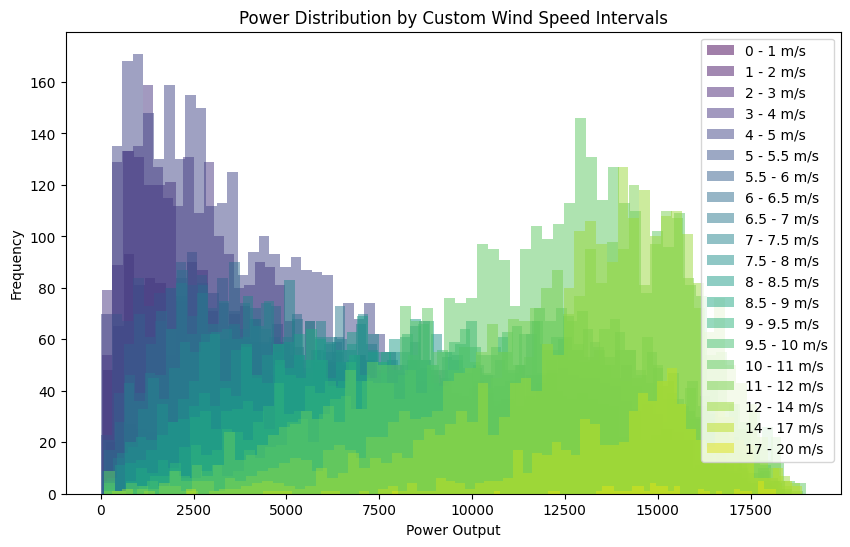

In [6]:
# custom wind speed intervals
intervals = [0, 1, 2, 3, 4, 5, 5.5, 6, 6.5, 7, 7.5, 8, 8.5, 9, 9.5, 10, 11, 12, 14, 17, 20]
bins = 64

fig, ax = plt.subplots(figsize=(10, 6))
for i in range(len(intervals) - 1):
    df_temp = df[(df['speed'] >= intervals[i]) & (df['speed'] < intervals[i + 1])]
    ax.hist(df_temp['power'], bins=bins, alpha=0.5, label=f'{intervals[i]} - {intervals[i + 1]} m/s', color=plt.cm.viridis(i/(len(intervals)-1)))

plt.legend()
plt.title('Power Distribution by Custom Wind Speed Intervals')
plt.xlabel('Power Output')
plt.ylabel('Frequency')

# Fitting a distribution

Text(0, 0.5, 'Frequency')

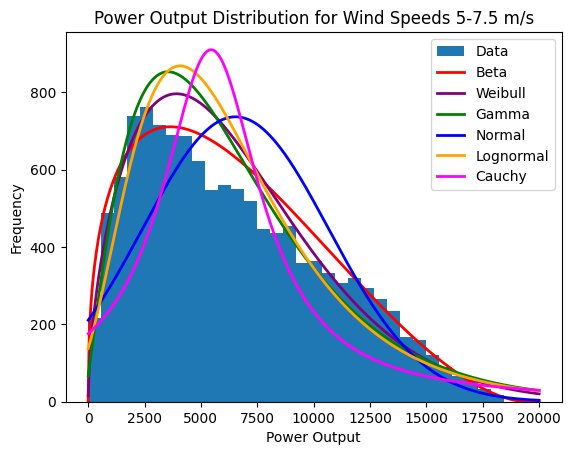

In [7]:
# fit distributions to the data for wind speeds
lower = 5
upper = 7.5

data = df[(df['speed'] >= lower) & (df['speed'] < upper)]['power']
plt.hist(data, bins=32, label='Data')
x = np.linspace(0, 20000, 500)

# beta
params_beta = beta.fit(data)
y1 = beta.pdf(x, *params_beta)
plt.plot(x, y1 * len(data) * (20000 / 32), color='red', lw=2, label='Beta')

# weibull
params_weibull = weibull_min.fit(data)
y2 = weibull_min.pdf(x, *params_weibull)
plt.plot(x, y2 * len(data) * (20000 / 32), color='purple', lw=2, label='Weibull')

# gamma
params_gamma = gamma.fit(data)
y3 = gamma.pdf(x, *params_gamma)
plt.plot(x, y3 * len(data) * (20000 / 32), color='green', lw=2, label='Gamma')

# normal
params_norm = norm.fit(data)
y_norm = norm.pdf(x, *params_norm)
plt.plot(x, y_norm * len(data) * (20000 / 32), color='blue', lw=2, label='Normal')

# lognormal
params_lognorm = lognorm.fit(data)
y4 = lognorm.pdf(x, *params_lognorm)
plt.plot(x, y4 * len(data) * (20000 / 32), color='orange', lw=2, label='Lognormal')

# cauchy
params_cauchy = cauchy.fit(data)
y5 = cauchy.pdf(x, *params_cauchy)
plt.plot(x, y5 * len(data) * (20000 / 32), color='magenta', lw=2, label='Cauchy')

plt.legend()
plt.title(f'Power Output Distribution for Wind Speeds {lower}-{upper} m/s')
plt.xlabel('Power Output')
plt.ylabel('Frequency')

In [8]:
# log likelihoods
loglik_beta = beta.logpdf(data, *params_beta).sum()
loglik_weibull = weibull_min.logpdf(data, *params_weibull).sum()
loglik_gamma = gamma.logpdf(data, *params_gamma).sum()
loglik_norm = norm.logpdf(data, *params_norm).sum()
loglik_lognorm = lognorm.logpdf(data, *params_lognorm).sum()
loglik_cauchy = cauchy.logpdf(data, *params_cauchy).sum()
print(f'Log Likelihoods:')
print(f'Beta : {loglik_beta}')
print(f'Weibull: {loglik_weibull}')
print(f'Gamma: {loglik_gamma}')
print(f'Normal: {loglik_norm}')
print(f'Lognormal: {loglik_lognorm}')
print(f'Cauchy: {loglik_cauchy}')

Log Likelihoods:
Beta : -117547.98367869908
Weibull: -117772.5257731221
Gamma: -117941.60460083658
Normal: -118957.97980490874
Lognormal: -118183.70887596523
Cauchy: -121633.7958384381


In [9]:
ks_beta = kstest(data, 'beta', args=params_beta)
ks_weibull = kstest(data, 'weibull_min', args=params_weibull)
ks_gamma = kstest(data, 'gamma', args=params_gamma)
ks_norm = kstest(data, 'norm', args=params_norm)
ks_lognorm = kstest(data, 'lognorm', args=params_lognorm)
ks_cauchy = kstest(data, 'cauchy', args=params_cauchy)

print("KS Beta:", ks_beta[0], "p-value:", ks_beta[1])
print("KS Weibull:", ks_weibull[0], "p-value:", ks_weibull[1])
print("KS Gamma:", ks_gamma[0], "p-value:", ks_gamma[1])
print("KS Normal:", ks_norm[0], "p-value:", ks_norm[1])
print("KS Lognormal:", ks_lognorm[0], "p-value:", ks_lognorm[1])
print("KS Cauchy:", ks_cauchy[0], "p-value:", ks_cauchy[1])

KS Beta: 0.026237458440603212 p-value: 9.848960151376317e-08
KS Weibull: 0.033308741654365814 p-value: 3.3505013394361865e-12
KS Gamma: 0.04163827801823561 p-value: 7.934803376027542e-19
KS Normal: 0.07989328040031157 p-value: 3.201471632383812e-68
KS Lognormal: 0.04577615726218809 p-value: 1.1480767868977723e-22
KS Cauchy: 0.14743785345951738 p-value: 4.4828317953072916e-232


In [10]:
distributions = {
    'beta': beta,
    'weibull_min': weibull_min,
    'gamma': gamma,
    'norm': norm,
    'lognorm': lognorm,
    'cauchy': cauchy
}

In [91]:
def get_best_dist(data):
    best_dist = None
    best_p = -np.inf
    
    for name, dist in distributions.items():
        try:
            params = dist.fit(data)
            p = kstest(data, name, args=params)[1]
            if p > best_p:
                best_p = p
                best_dist = name
        except Exception as e:
            print(f"Error fitting {name} distribution: {e}")
    return best_dist, best_p

In [12]:
def plot_distribution_fits(data, intervals, bins=32):
    num_intervals = len(intervals) - 1
    if (num_intervals % 2) != 0:
        num_intervals += 1
    height = num_intervals // 2
    
    fig, axs = plt.subplots(height, 2, figsize=(12, height*3))

    for i in range(num_intervals):
        lower = intervals[i]
        upper = intervals[i+1]
        power = data[(data['speed'] >= lower) & (data['speed'] < upper)]['power']

        ax = axs[i//2, i%2]
        ax.hist(power, bins=bins)
        
        # get best distribution and plot it
        best_dist, best_p = get_best_dist(power)
        params = distributions[best_dist].fit(power)
        x = np.linspace(0, 20000, 500)
        y = distributions[best_dist].pdf(x, *params)
        ax.plot(x, y * len(power) * (20000 / bins), color='red', label=f'{best_dist} (p={best_p:.4f})')

        ax.set_title(f'Wind Speed {lower}-{upper} m/s')
        ax.set_xlabel('Power Output')
        ax.set_ylabel('Frequency')
        ax.legend()
    
    fig.suptitle('Best Distribution Fits for Power Output by Wind Speed Intervals', fontsize=16, y=0.995)
    plt.tight_layout()
    plt.show()

In [78]:
def get_all_distributions(data, intervals):
    fitted_distributions = {}
    num_intervals = len(intervals) - 1

    for i in range(num_intervals):
        lower = intervals[i]
        upper = intervals[i + 1]
        power = data[(data['speed'] >= lower) & (data['speed'] < upper)]['power']

        best_dist, best_p = get_best_dist(power)

        fitted_distributions[f'{lower}-{upper}'] = {
            'distribution': best_dist,
            'params': distributions[best_dist].fit(power),
            'p_value': best_p
        }
        
    return fitted_distributions


/Users/jessicayao/miniconda3/envs/blog_loneliness/lib/python3.12/site-packages/scipy/stats/_continuous_distns.py:795: RuntimeWarning: invalid value encountered in sqrt
  sk = 2*(b-a)*np.sqrt(a + b + 1) / (a + b + 2) / np.sqrt(a*b)
/Users/jessicayao/miniconda3/envs/blog_loneliness/lib/python3.12/site-packages/scipy/stats/_continuous_distns.py:800: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  a, b = optimize.fsolve(func, (1.0, 1.0))


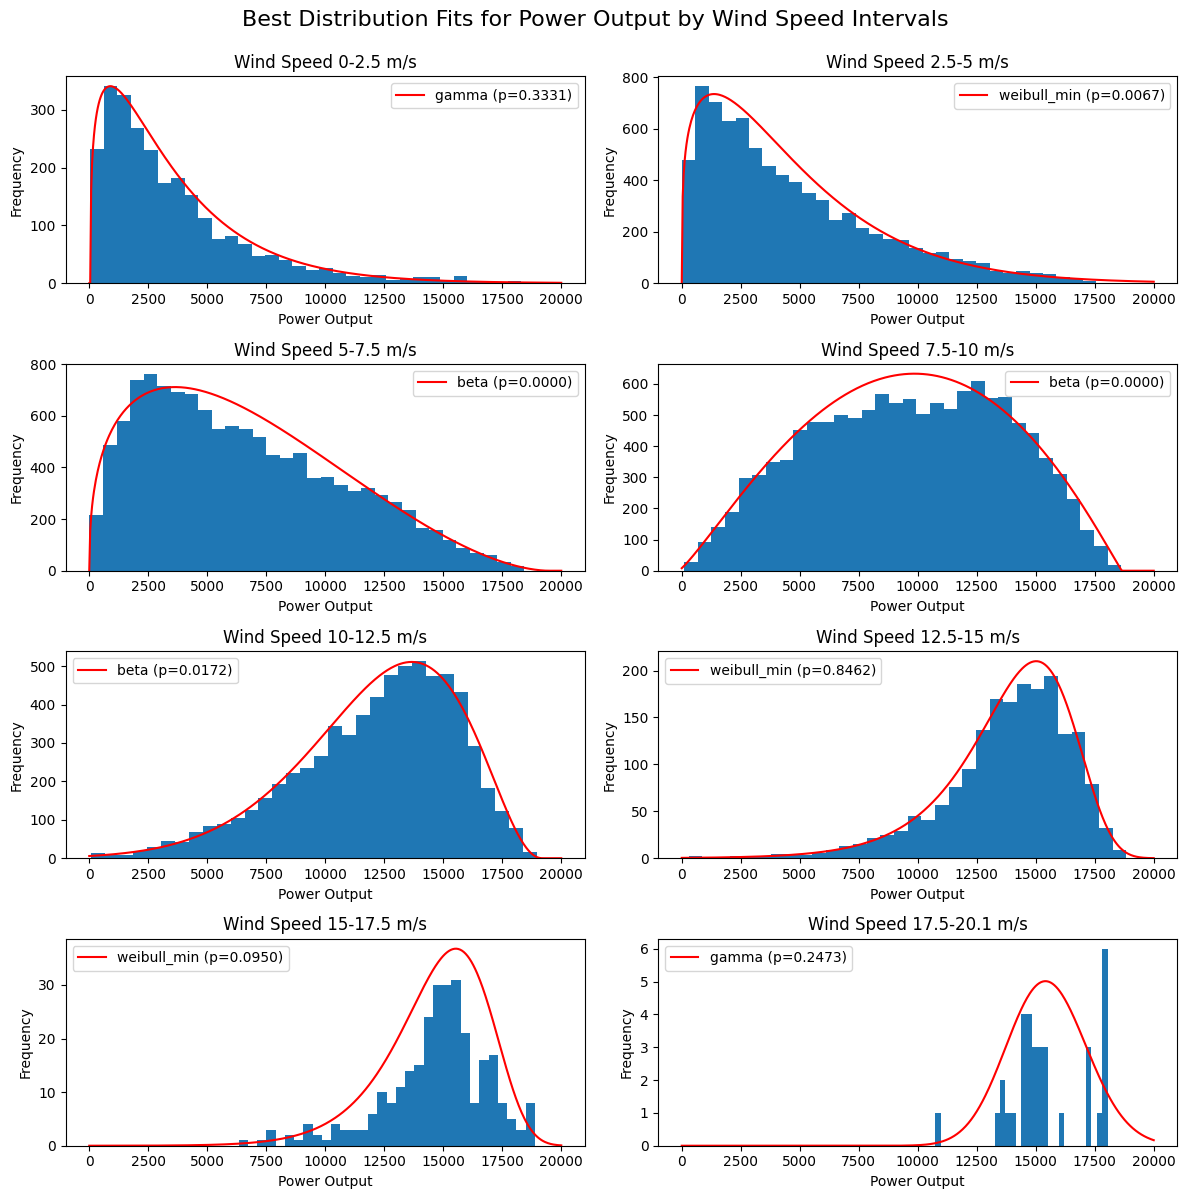

In [14]:
intervals = [0, 2.5, 5, 7.5, 10, 12.5, 15, 17.5, 20.1]
plot_distribution_fits(df, intervals, bins=32)
fitted = get_all_distributions(df, intervals)

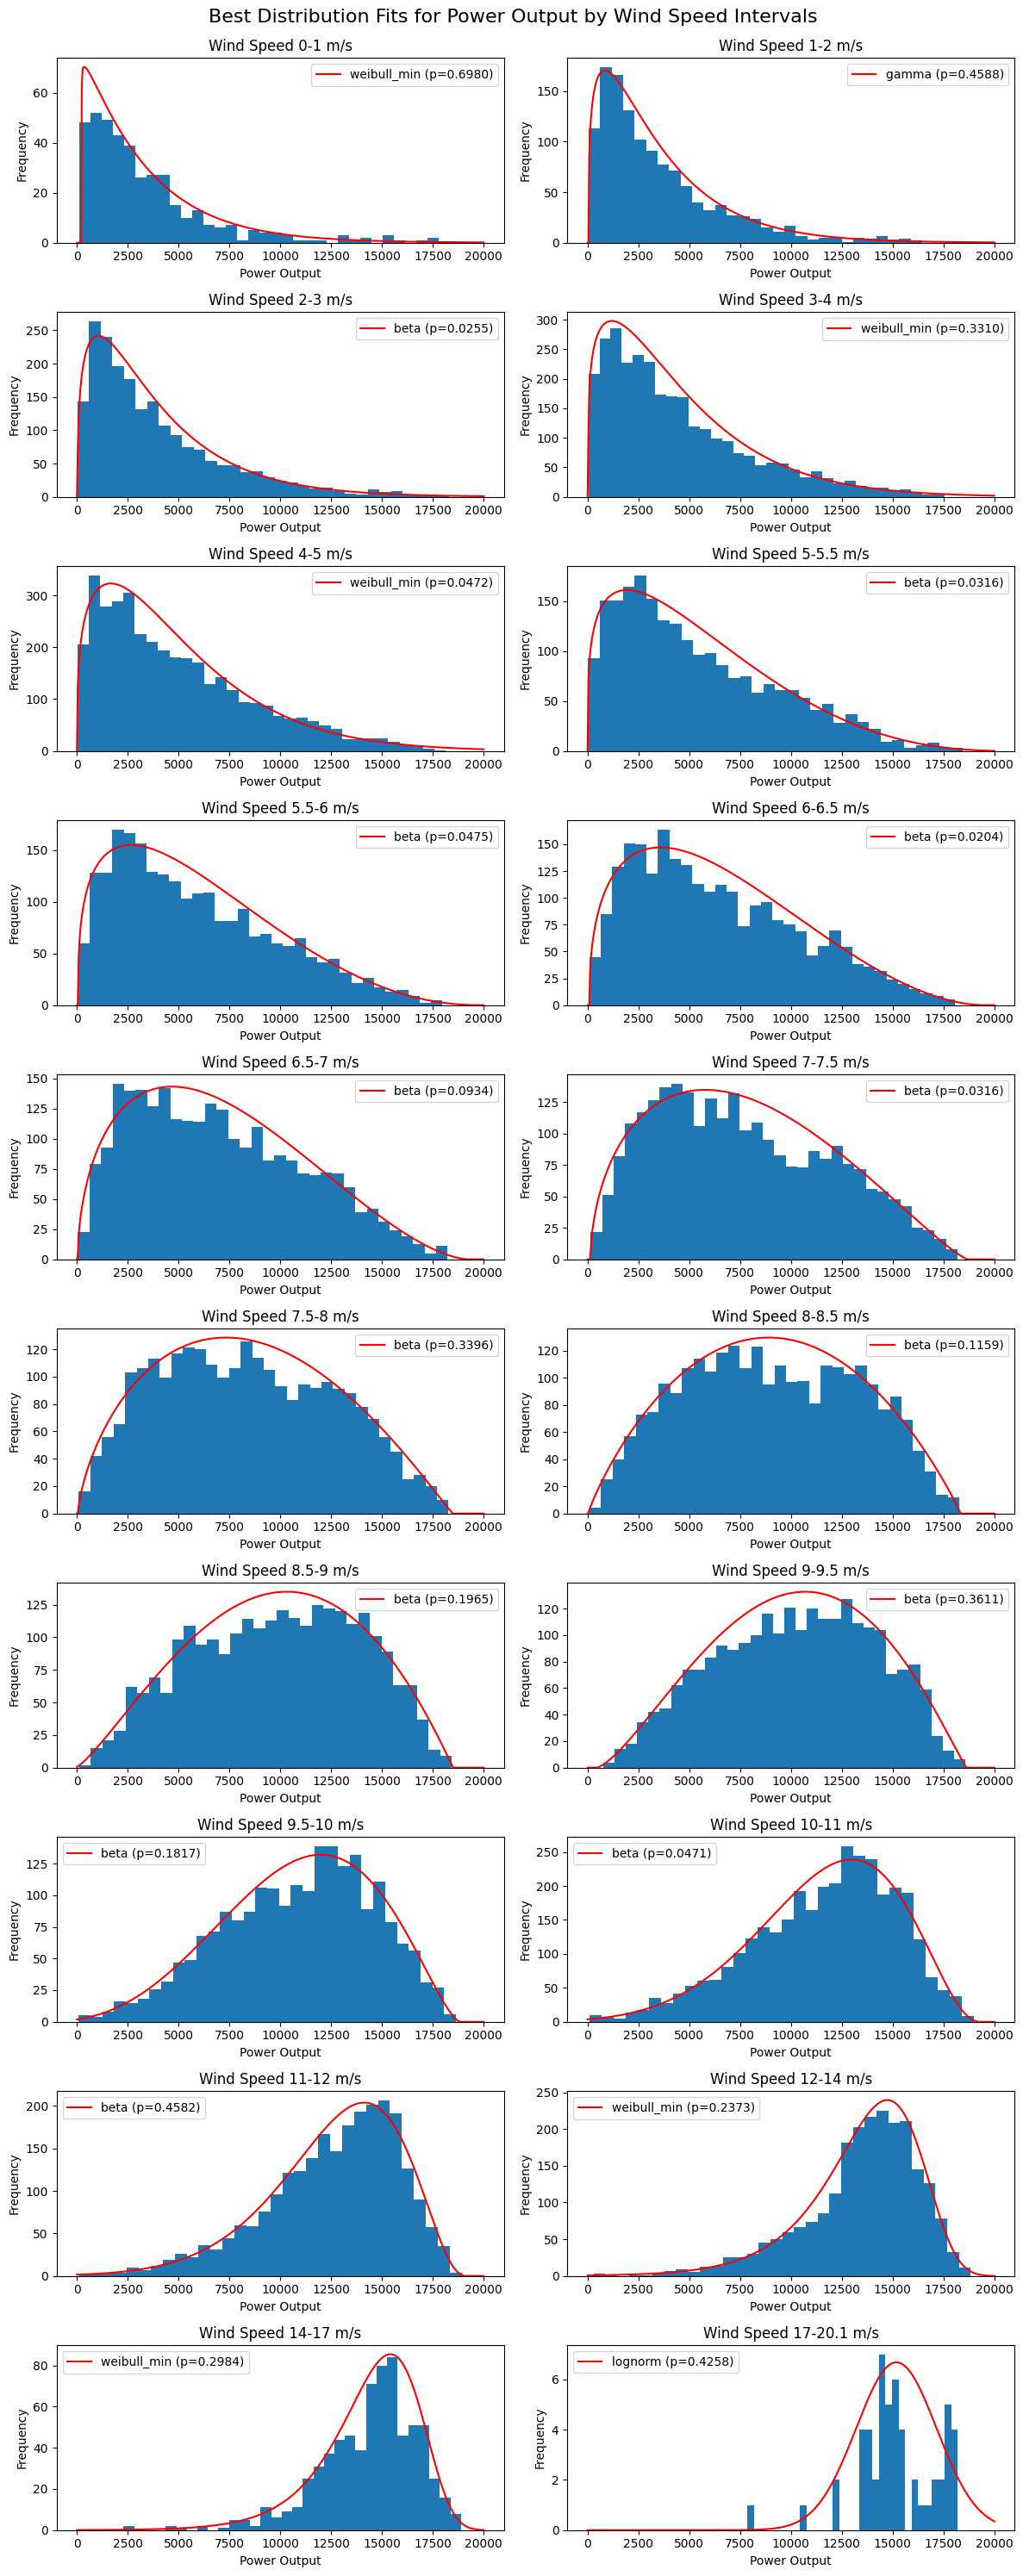

In [15]:
intervals = [0, 1, 2, 3, 4, 5, 5.5, 6, 6.5, 7, 7.5, 8, 8.5, 9, 9.5, 10, 11, 12, 14, 17, 20.1]
plot_distribution_fits(df, intervals, bins=32)
fitted = get_all_distributions(df, intervals)

## Sampling from the fitted distributions

In [ ]:
def sample_from_fits(fitted_distributions, num_samples=1000):
    samples = []
    for interval, fit in fitted_distributions.items():
        dist = distributions[fit['distribution']]
        params = fit['params']
        sampled_data = dist.rvs(*params, size=num_samples)
        samples.append(pd.DataFrame({
            'interval': interval,
            'sampled_power': sampled_data
        }))
    return pd.concat(samples, ignore_index=True)

In [83]:
def sample_power(speeds, fitted_distributions, intervals, num_samples=1):
    sampled_data = []
    for speed in speeds:
        for i in range(len(intervals) - 1):
            lower = intervals[i]
            upper = intervals[i + 1]
            if lower <= speed < upper:
                fit = fitted_distributions[f'{lower}-{upper}']
                dist = distributions[fit['distribution']]
                params = fit['params']

                # avoid sampling out of the range 0 to 20000
                sampled_power = np.mean(dist.rvs(*params, size=num_samples))
                sampled_power = max(0, min(sampled_power, 20000))

                sampled_data.append({
                    'speed': speed,
                    'sampled_power': sampled_power
                })
                break
    return pd.DataFrame(sampled_data)

MSE: 28151835.861667477


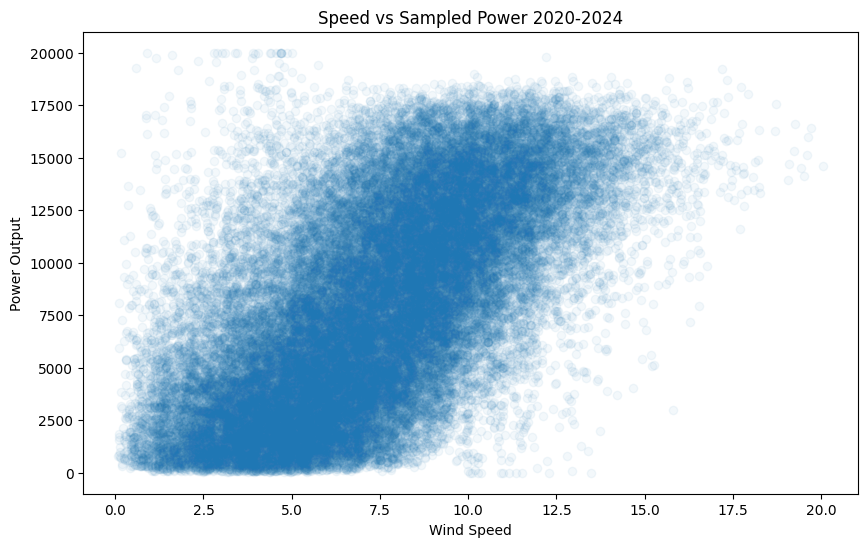

In [119]:
intervals = [0, 1, 2, 3, 4, 5, 5.5, 6, 6.5, 7, 7.5, 8, 8.5, 9, 9.5, 10, 11, 12, 14, 17, 20.1]
fitted = get_all_distributions(df, intervals)

samples = sample_power(df['speed'], fitted, intervals, num_samples=1)
df_samples = pd.merge(df, samples, on='speed', how='left')

plt.figure(figsize=(10, 6))
plt.scatter(df_samples['speed'], df_samples['sampled_power'], alpha=0.05)
plt.title('Speed vs Sampled Power 2020-2024')
plt.xlabel('Wind Speed')
plt.ylabel('Power Output')

mse = mean_squared_error(df_samples['power'], df_samples['sampled_power'])
print('MSE:', mse)

plt.show()

In [65]:
mean_squared_error(df_samples['power'], df_samples['sampled_power'])

14220820.0936898

In [62]:
print(df_samples['power'].sum())
print(df_samples['sampled_power'].sum())

356351028.93
356105648.9906194


In [22]:
int_size = 0.5
intervals = np.arange(0, 20.05+int_size, int_size)
intervals

array([ 0. ,  0.5,  1. ,  1.5,  2. ,  2.5,  3. ,  3.5,  4. ,  4.5,  5. ,
        5.5,  6. ,  6.5,  7. ,  7.5,  8. ,  8.5,  9. ,  9.5, 10. , 10.5,
       11. , 11.5, 12. , 12.5, 13. , 13.5, 14. , 14.5, 15. , 15.5, 16. ,
       16.5, 17. , 17.5, 18. , 18.5, 19. , 19.5, 20. , 20.5])

In [43]:
def merge_intervals(df, base_intervals, min_points):
    merged_intervals = []
    i = 0
    while i < len(base_intervals) - 1:
        j = i + 1
        while j < len(base_intervals):
            lower = np.round(base_intervals[i], 3)
            upper = np.round(base_intervals[j], 3)
            power = df[(df['speed'] >= lower) & (df['speed'] < upper)]['power']
            if len(power) >= min_points:
                break
            j += 1
        merged_intervals.append(lower)
        i = j
    merged_intervals.append(base_intervals[-1])
    return merged_intervals

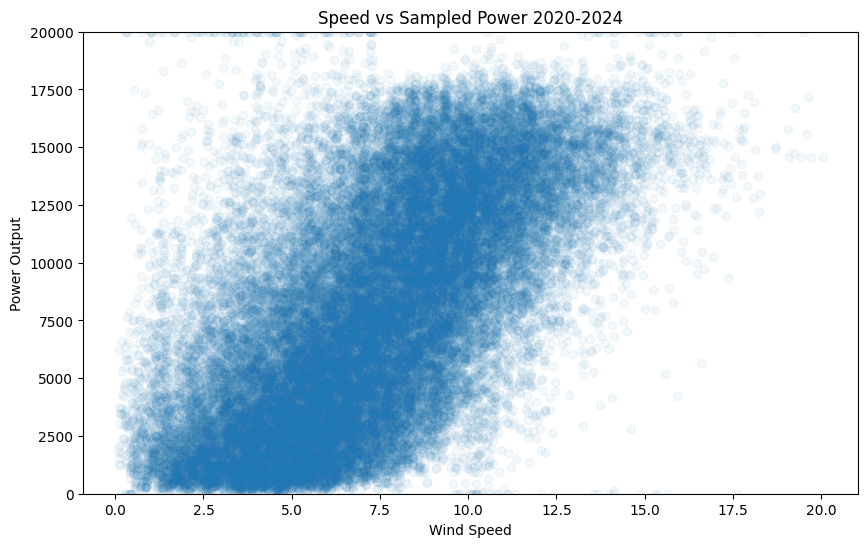

Mean Squared Error: 28202790.86891759


In [101]:
min_points = 10
int_size = 0.05
base_intervals = np.arange(0, 20.05 + int_size, int_size)
intervals = merge_intervals(df, base_intervals, min_points)
fitted = get_all_distributions(df, intervals)

samples = sample_power(df['speed'], fitted, intervals)
df_samples = pd.merge(df, samples, on='speed', how='left')

plt.figure(figsize=(10, 6))
plt.scatter(df_samples['speed'], df_samples['sampled_power'], alpha=0.05)
plt.title('Speed vs Sampled Power 2020-2024')
plt.xlabel('Wind Speed')
plt.ylabel('Power Output')
plt.ylim(0, 20000)
plt.show()

mse = mean_squared_error(df_samples['power'], df_samples['sampled_power'])
print(f'Mean Squared Error: {mse}')

In [ ]:
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [103]:
# loop through interval sizes and print the mean squared error, get the best interval size
interval_sizes = np.arange(0.05, 1.05, 0.05)
mse_vals = []
best_mse = float('inf')
best_size = None

for int_size in interval_sizes:
    base_intervals = np.arange(0, 20.05 + int_size, int_size)
    intervals = merge_intervals(df, base_intervals, min_points)
    fitted = get_all_distributions(df, intervals)
    
    samples = sample_power(df['speed'], fitted, intervals)
    df_samples = pd.merge(df, samples, on='speed', how='left')
    
    mse = mean_squared_error(df_samples['power'], df_samples['sampled_power'])
    mse_vals.append(mse)
    print(f'Interval size: {int_size:.2f}, MSE: {mse:.2f}')
    
    if mse < best_mse:
        best_mse = mse
        best_size = int_size

Interval size: 0.05, MSE: 28466168.63
Interval size: 0.10, MSE: 28210983.41
Interval size: 0.15, MSE: 28042653.87
Interval size: 0.20, MSE: 27890163.52
Interval size: 0.25, MSE: 28179624.11
Interval size: 0.30, MSE: 28040243.14
Interval size: 0.35, MSE: 27999472.00
Interval size: 0.40, MSE: 28254450.88
Interval size: 0.45, MSE: 28270654.08
Interval size: 0.50, MSE: 28259325.64
Error fitting gamma distribution: Optimization converged to parameters that are outside the range allowed by the distribution.
Interval size: 0.55, MSE: 28192693.30
Interval size: 0.60, MSE: 28348264.08
Interval size: 0.65, MSE: 28183164.24
Interval size: 0.70, MSE: 28283747.51
Interval size: 0.75, MSE: 28384153.90
Error fitting gamma distribution: Optimization converged to parameters that are outside the range allowed by the distribution.
Interval size: 0.80, MSE: 28531045.13
Interval size: 0.85, MSE: 28004041.77
Error fitting gamma distribution: Optimization converged to parameters that are outside the range al

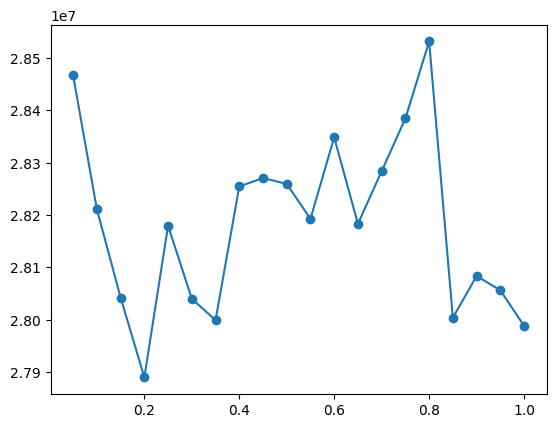

In [104]:
plt.plot(interval_sizes, mse_vals, marker='o')

## Generating time series from power generated

Mean Squared Error: 27942236.023307372


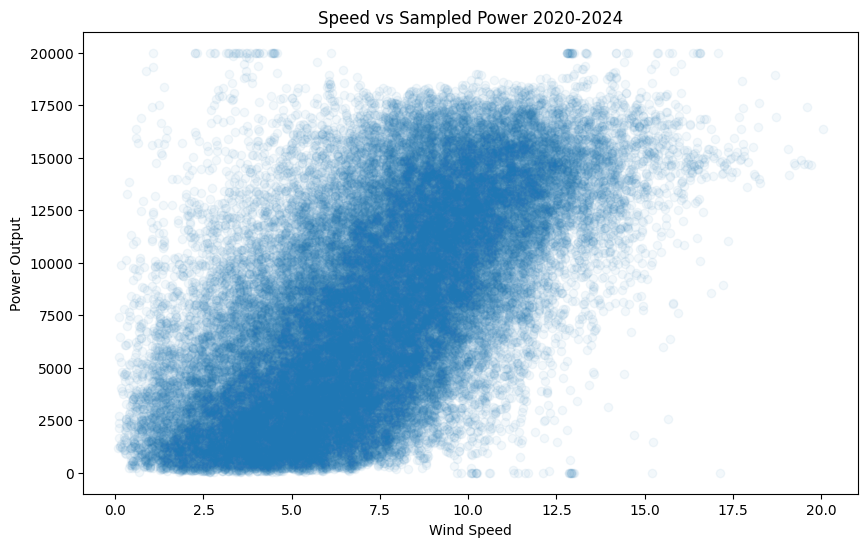

In [109]:
min_points = 10
int_size = 0.2
base_intervals = np.arange(0, 20.05 + int_size, int_size)
intervals = merge_intervals(df, base_intervals, min_points)
fitted = get_all_distributions(df, intervals)

samples = sample_power(df['speed'], fitted, intervals, num_samples=1)
df_samples = pd.merge(df, samples, on='speed', how='left')

plt.figure(figsize=(10, 6))
plt.scatter(df_samples['speed'], df_samples['sampled_power'], alpha=0.05)
plt.title('Speed vs Sampled Power 2020-2024')
plt.xlabel('Wind Speed')
plt.ylabel('Power Output')

mse = mean_squared_error(df_samples['power'], df_samples['sampled_power'])
print(f'Mean Squared Error: {mse}')

plt.show()

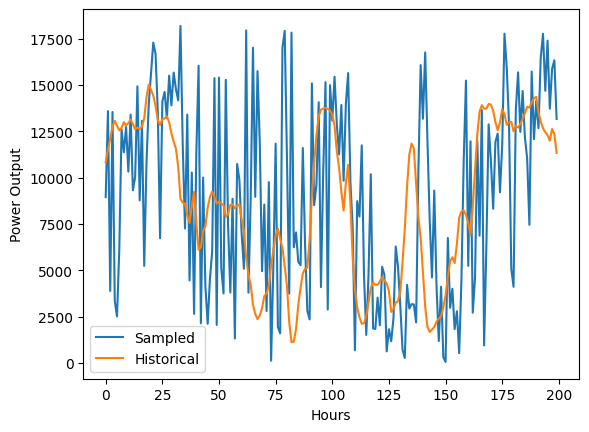

In [118]:
plt.plot(df_samples['sampled_power'][:200], label='Sampled')
plt.plot(df_samples['power'][:200], label='Historical')
plt.xlabel('Hours')
plt.ylabel('Power Output')
plt.legend()

## Using simulated power